# 03 — Explicabilité des Modèles
## Projet ObRail Europe — Prévision de fréquentation & Détection des pays en déclin

**Objectif :** Produire les visualisations d'explicabilité des modèles sélectionnés :
- Importance des variables — XGBoost optimisé (classification)
- Analyse SHAP globale — XGBoost optimisé (classification)
- Explication SHAP individuelle — XGBoost optimisé (classification)
- Importance des variables via les coefficients — Ridge baseline (régression)
- Analyse SHAP globale — Ridge baseline (régression)
- Figures finales exportées pour la documentation

**Variables attendues comme importantes :** 
- passengers_lag1 → dynamique récente (signal le plus fort)
- passengers_lag2 → tendance historique sur deux années
- co2_per_passenger → indicateur d'efficacité environnementale
- year → évolution temporelle globale

**Livrables :** 
- notebooks/03_explicabilite.ipynb
- docs/ia/img/fig_feature_importance_clf.png
- docs/ia/img/fig_feature_importance_reg.png
- docs/ia/img/fig_shap_clf.png
- docs/ia/img/fig_shap_reg.png

In [1]:
# Imports principaux pour les chemins, données, graphiques et explicabilité.
from pathlib import Path
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import warnings
warnings.filterwarnings("ignore", message=r".*Trying to unpickle estimator Ridge.*")
warnings.filterwarnings("ignore", message=r".*feature_perturbation option is now deprecated.*")



# Recherche automatique de la racine du projet.
ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / 'ia').exists() and (parent / 'docs').exists():
        ROOT = parent
        break
sys.path.insert(0, str(ROOT))


# Dossier où les figures finales seront exportées.
def find_docs_dir():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        candidate = p / 'docs' / 'ia' / 'img' / 'explicability'
        if candidate.exists():
            return candidate
    return ROOT / 'docs' / 'ia' / 'img' / 'explicability'

DOCS_DIR = find_docs_dir()
DOCS_DIR.mkdir(parents=True, exist_ok=True)


# Fonctions projet pour charger les datasets, preprocessors et modèles.
from ia.src.ml.models.train_utils import (
    load_classification_data, prepare_classification_data,
    load_regression_data, prepare_regression_data,
    load_model_and_metrics
)


# Style visuel commun aux graphiques du notebook.
sns.set(style="whitegrid")


---
## Bloc 1. Classification (XGBoost optimisé)
Nous utilisons le modèle `xgboost_optimized` (axis='clf').

In [2]:
# Chargement et preprocessing du dataset de classification.
X_clf, y_clf = load_classification_data()
prepared_clf = prepare_classification_data(X_clf, y_clf)
X_train_p, X_test_p = prepared_clf.X_train, prepared_clf.X_test
y_train_clf, y_test_clf = prepared_clf.y_train, prepared_clf.y_test
preprocessor_clf = prepared_clf.preprocessor

# Récupération des noms de variables après transformation.
try:
    feature_names_clf = preprocessor_clf.get_feature_names_out()
except Exception:
    feature_names_clf = list(preprocessor_clf.transformers_[0][2]) + list(preprocessor_clf.transformers_[1][2])


# Chargement du modèle XGBoost optimisé, avec fallback si besoin.
try:
    xgb_model, _ = load_model_and_metrics('xgboost_optimized', axis='clf')
except Exception as e:
    print('Chargement via helper failed:', e)
    alt = Path('ia/models/xgboost_optimized_clf.joblib')
    if alt.exists():
        xgb_model = joblib.load(alt)
    else:
        raise FileNotFoundError('Modele XGBoost classification introuvable (ia/models/xgboost_optimized_clf.joblib)')


   [Classification] 390 observations | 30 pays | 2012-2024
   Distribution cible : {0: 280, 1: 110}
   Qualité source : {'observed': 335, 'mixed': 52, 'synthetic_or_unknown': 3}
   Split temporel : train 2012-2019 (240 obs) | test 2020-2024 (150 obs)
   Features transformées : 36


c:\Python313\Lib\pickle.py:1760: UserWarning: [22:55:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


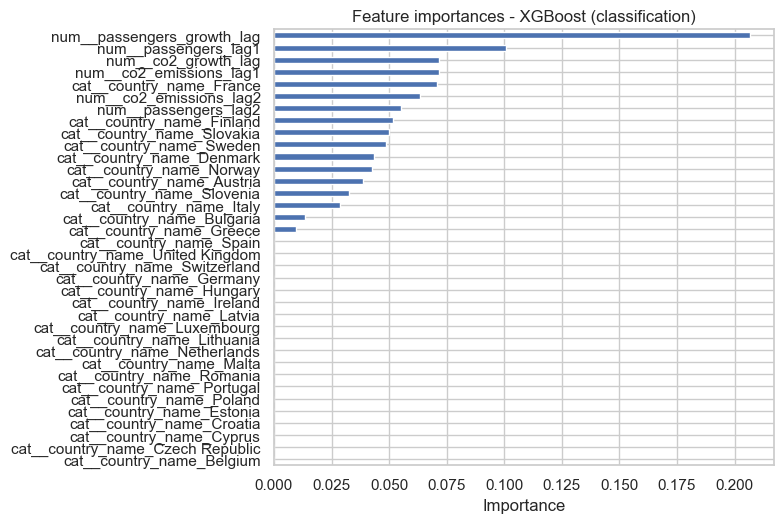

In [3]:
# Extraction de l'importance native des variables XGBoost.
importances = xgb_model.feature_importances_
if len(importances) == len(feature_names_clf):
    s = pd.Series(importances, index=feature_names_clf)
else:
    s = pd.Series(importances)

# Tri pour afficher les variables les plus importantes en haut du graphique.
s = s.sort_values(ascending=True)

# Création et sauvegarde du graphique d'importance.
plt.figure(figsize=(8, max(4, len(s) * 0.15)))
s.plot(kind='barh', color='C0')
plt.title('Feature importances - XGBoost (classification)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_feature_importance_clf.png', dpi=150)
plt.show()


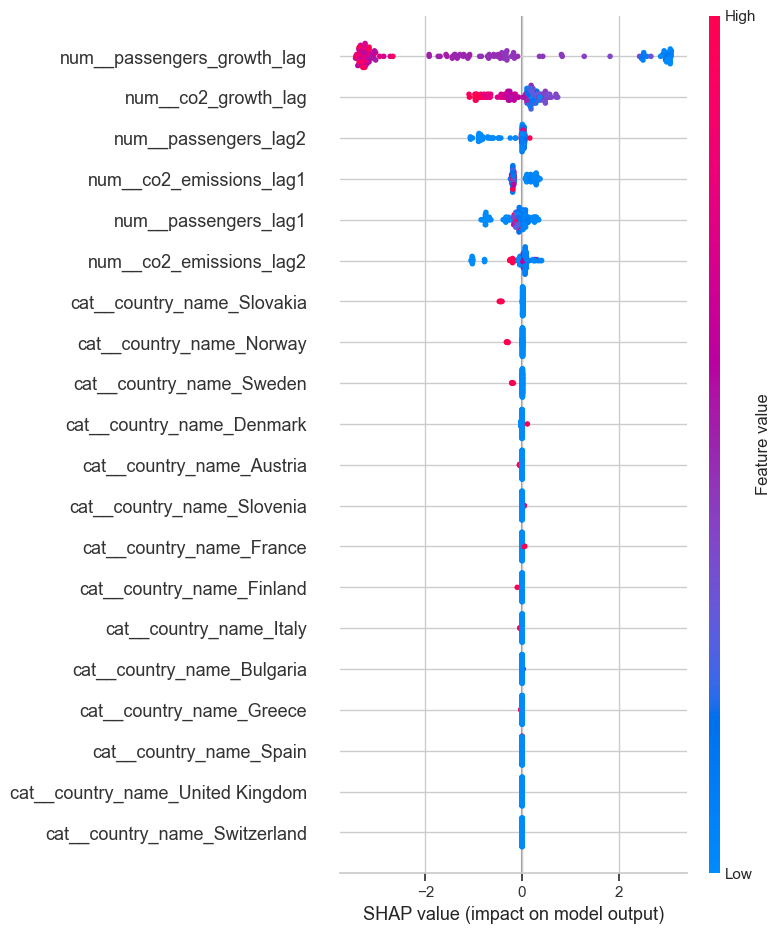

In [4]:
# Initialisation de SHAP pour expliquer les prédictions XGBoost.
explainer = shap.TreeExplainer(xgb_model)

# Limitation de l'échantillon si le test set est trop grand.
X_for_shap = X_test_p if X_test_p.shape[0] <= 2000 else X_test_p[np.random.choice(X_test_p.shape[0], 2000, replace=False)]

# Calcul des valeurs SHAP avec compatibilité entre versions.
try:
    shap_exp = explainer(X_for_shap)
    shap_values = shap_exp.values
except Exception:
    shap_values = explainer.shap_values(X_for_shap)


# Visualisation globale de l'effet des variables sur la prédiction.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_for_shap, feature_names=feature_names_clf, show=False)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_shap_clf.png', dpi=150)
plt.show()


---
## Bloc 2. Régression (Ridge baseline)
Nous utilisons le modèle `ridge` (axis='reg').

In [5]:
# Chargement et preprocessing du dataset de régression.
X_reg, y_reg = load_regression_data()
prepared_reg = prepare_regression_data(X_reg, y_reg)
X_train_p_reg, X_test_p_reg = prepared_reg.X_train, prepared_reg.X_test
y_train_reg, y_test_reg = prepared_reg.y_train, prepared_reg.y_test
preprocessor_reg = prepared_reg.preprocessor

# Récupération des noms de variables après transformation.
try:
    feature_names_reg = preprocessor_reg.get_feature_names_out()
except Exception:
    feature_names_reg = list(preprocessor_reg.transformers_[0][2]) + list(preprocessor_reg.transformers_[1][2])


# Chargement du modèle Ridge retenu, avec fallback si besoin.
try:
    ridge_model, _ = load_model_and_metrics('ridge', axis='reg')
except Exception as e:
    print('Chargement via helper failed:', e)
    alt = Path('ia/models/ridge_reg.joblib')
    if alt.exists():
        ridge_model = joblib.load(alt)
    else:
        raise FileNotFoundError('Modele Ridge regression introuvable (ia/models/ridge_reg.joblib)')


   [Régression] 390 observations | 30 pays | 2012-2024
   Cible passengers (MIO_PKM) : min=0.00 | médiane=4651.50 | max=109135.00
   Qualité source : {'observed': 335, 'mixed': 52, 'synthetic_or_unknown': 3}
   Split temporel : train 2012-2019 (240 obs) | test 2020-2024 (150 obs)
   Features transformées : 36


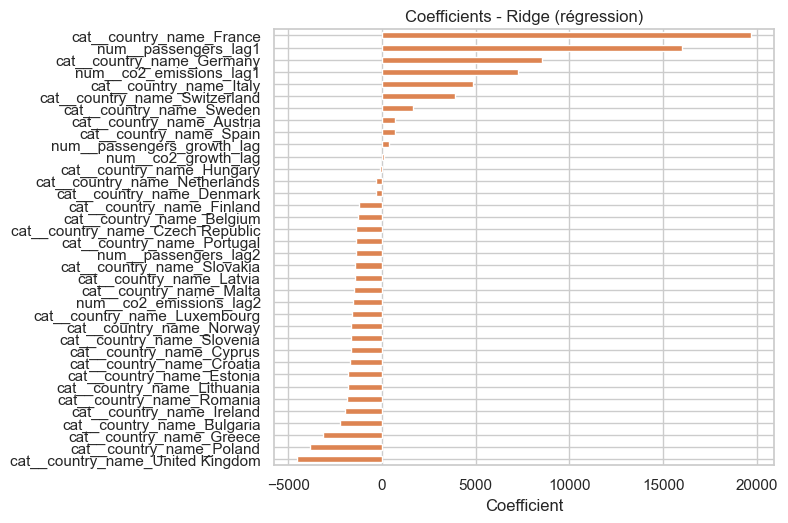

In [6]:
# Extraction des coefficients Ridge comme mesure d'influence des variables.
coefs = pd.Series(ridge_model.coef_, index=feature_names_reg) if len(ridge_model.coef_) == len(feature_names_reg) else pd.Series(ridge_model.coef_)

# Tri puis visualisation des coefficients positifs et négatifs.
coefs = coefs.sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(coefs) * 0.15)))
coefs.plot(kind='barh', color='C1')
plt.title('Coefficients - Ridge (régression)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_feature_importance_reg.png', dpi=150)
plt.show()


Background dataset has 240 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=240 when initializing the masker.


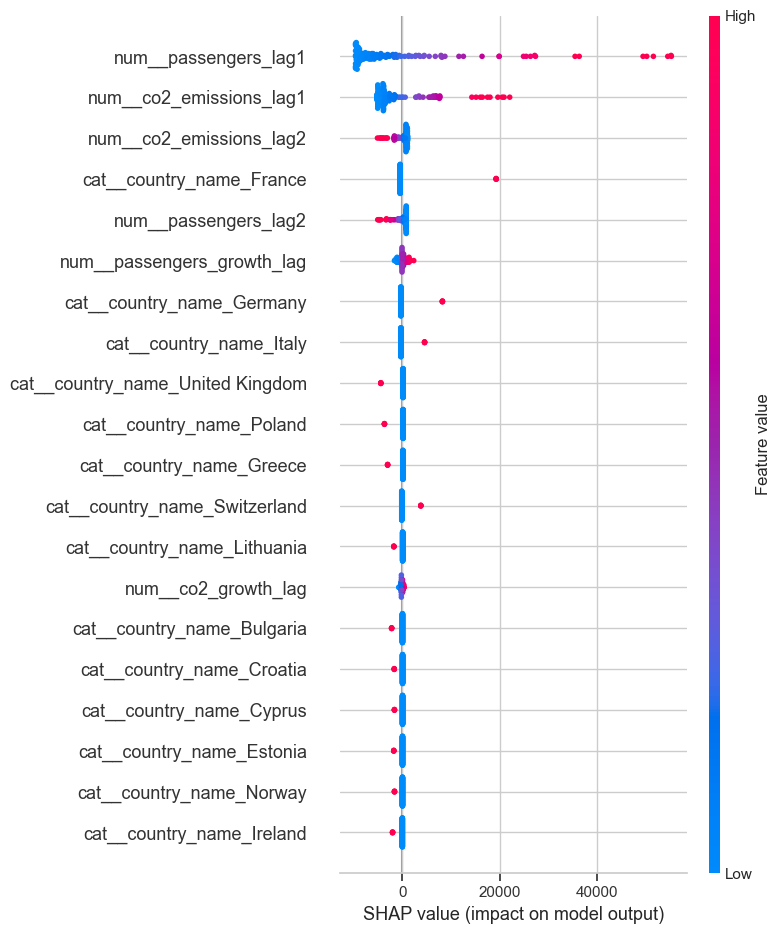

In [7]:
# Initialisation de SHAP pour le modèle lineaire Ridge.
explainer_reg = shap.LinearExplainer(ridge_model, X_train_p_reg, feature_perturbation="interventional")

# Calcul des valeurs SHAP avec compatibilité entre versions.
try:
    shap_exp_reg = explainer_reg(X_test_p_reg)
    shap_values_reg = shap_exp_reg.values
except Exception:
    shap_values_reg = explainer_reg.shap_values(X_test_p_reg)


# Visualisation globale de l'effet des variables sur la prédiction.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_test_p_reg, feature_names=feature_names_reg, show=False)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_shap_reg.png', dpi=150)
plt.show()
